# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [ ]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [ ]:
# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

# TODO: list CSV files under EXTRACT_DIR
csv_path = None  # set to the CSV you choose

# TODO: load the CSV into a DataFrame named df
df = None

# TODO: inspect df

# TODO: identify target column
target = None  # 'target'

# TODO: split features and target
X = None  # df.drop(columns=[...])
y = None  # df[...]

# TODO: train test split with stratification
X_train, X_test, y_train, y_test = None, None, None, None
# Hint: train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


In [ ]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split

df = pd.read_csv("Heart_data.csv")
df.head()


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels      

In [ ]:
df.describe()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
chest pain type,0
resting blood pressure,0
serum cholestoral,0
fasting blood sugar,0
resting electrocardiographic results,0
max heart rate,0
exercise induced angina,0
oldpeak,0


In [ ]:
X = df.drop("heart disease", axis=1)
y = df["heart disease"]

print(type(X))
print(type(y))
print(X.shape)
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(270, 13)
(270,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(216, 13)
(54, 13)
(216,)
(54,)


### Basic visual checks

In [ ]:
print(df.columns)

Index(['age', 'sex ', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'fasting blood sugar',
       'resting electrocardiographic results', 'max heart rate',
       'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels',
       'thal', 'heart disease'],
      dtype='object')


In [ ]:
# TODO: pick a few numeric columns and plot histograms


# TODO: plot class balance as a bar chart



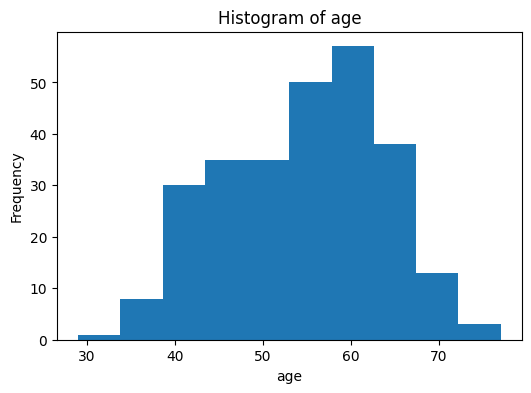

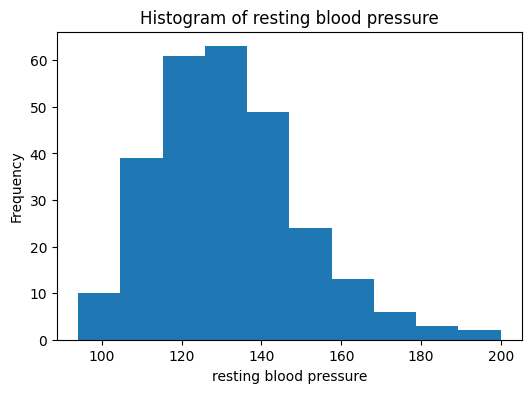

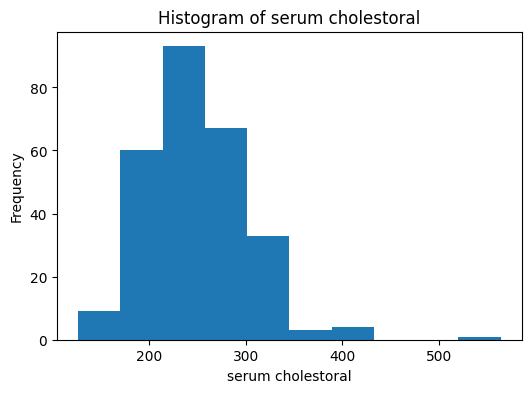

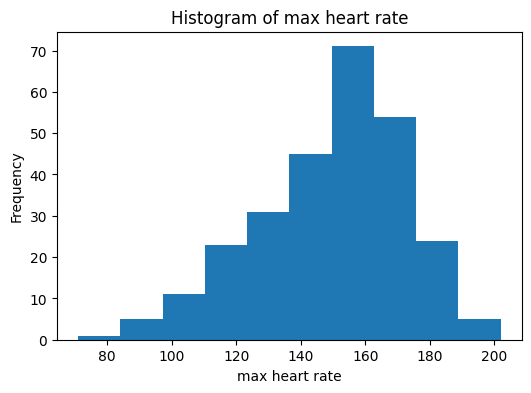

In [ ]:
# Pick a few numeric columns and plot histograms

numeric_cols = ["age", "resting bp s", "cholesterol", "max heart rate"]

numeric_cols = [
    "age",
    "resting blood pressure",
    "serum cholestoral",
    "max heart rate"
]
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=10)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

plt.show()

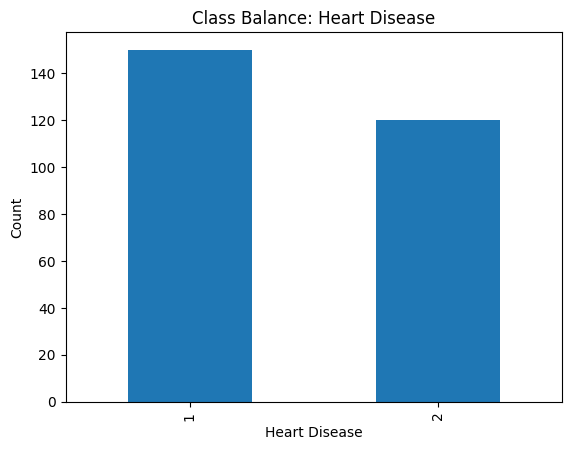

In [ ]:
# Plot class balance as a bar chart

df["heart disease"].value_counts().plot(kind="bar")

plt.title("Class Balance: Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

## Preprocessing pipeline

In [ ]:
cat_cols = None  # list of object, category, or bool columns
num_cols = None  # list of numeric columns

# TODO: build a ColumnTransformer named pre
pre = None



## Helper - evaluation function

In [ ]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = None  # model.predict(...)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': None,
        'precision': None,
        'recall': None,
        'f1': None,
    }
    print(name, metrics)

    # TODO: confusion matrix plot
    # Hint: confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay

    # TODO: ROC curve if model has predict_proba

    return metrics


## Exercise 2 - Logistic Regression without Grid Search

In [ ]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = None

# TODO: fit on training data
# pipe_lr.fit(...)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = None


In [ ]:
X = df.drop("heart disease", axis=1)
y = df["heart disease"]

In [ ]:
print(X.head())
print(y.head())

   age  sex   chest pain type  resting blood pressure  serum cholestoral  \
0   70     1                4                     130                322   
1   67     0                3                     115                564   
2   57     1                2                     124                261   
3   64     1                4                     128                263   
4   74     0                2                     120                269   

   fasting blood sugar  resting electrocardiographic results  max heart rate  \
0                    0                                     2             109   
1                    0                                     2             160   
2                    0                                     0             141   
3                    0                                     0             105   
4                    0                                     2             121   

   exercise induced angina  oldpeak  ST segment  major vessels

In [ ]:
print(y.head())

0    2
1    1
2    2
3    1
4    1
Name: heart disease, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(216, 13)
(54, 13)
(216,)
(54,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: []
Numeric columns: ['age', 'sex ', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal']


In [ ]:
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols)
    ],
    remainder="passthrough"
)

In [ ]:
pipe_lr = Pipeline([
    ("preprocessor", pre),
    ("model", LogisticRegression(solver="liblinear", max_iter=1000))
])

pipe_lr.fit(X_train, y_train)

y_pred = pipe_lr.predict(X_test)

lr_no_gs_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred)
}

print(lr_no_gs_metrics)

{'accuracy': 0.9074074074074074, 'precision': 0.9117647058823529, 'recall': 0.9393939393939394, 'f1': 0.9253731343283582}


## Exercise 3 - Logistic Regression with Grid Search

In [ ]:
# TODO: build a Pipeline same as above
pipe_lr_cv = None

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    # 'lr__C': [...],
    # 'lr__penalty': [...],
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = None
# grid_lr.fit(...)
# print('Best params:', grid_lr.best_params_)
# best_lr = grid_lr.best_estimator_
# lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)


In [ ]:
from sklearn.model_selection import GridSearchCV

pipe_lr_cv = Pipeline([
    ("preprocessor", pre),
    ("lr", LogisticRegression(solver="liblinear", max_iter=1000))
])

param_grid = {
    "lr__C": [0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l1", "l2"]
}

grid_lr = GridSearchCV(
    pipe_lr_cv,
    param_grid,
    cv=5,
    scoring="f1"
)

grid_lr.fit(X_train, y_train)

print("Best params:", grid_lr.best_params_)

best_lr = grid_lr.best_estimator_

y_pred_grid = best_lr.predict(X_test)

lr_gs_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_grid),
    "precision": precision_score(y_test, y_pred_grid),
    "recall": recall_score(y_test, y_pred_grid),
    "f1": f1_score(y_test, y_pred_grid)
}

print(lr_gs_metrics)

Best params: {'lr__C': 1, 'lr__penalty': 'l2'}
{'accuracy': 0.9074074074074074, 'precision': 0.9117647058823529, 'recall': 0.9393939393939394, 'f1': 0.9253731343283582}


## Exercise 4 - SVM without Grid Search

In [ ]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = None
# pipe_svm.fit(...)
# svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)


In [ ]:
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ("preprocessor", pre),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

pipe_svm.fit(X_train, y_train)

y_pred_svm = pipe_svm.predict(X_test)

svm_no_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_svm),
    "precision": precision_score(y_test, y_pred_svm),
    "recall": recall_score(y_test, y_pred_svm),
    "f1": f1_score(y_test, y_pred_svm)
}

print(svm_no_metrics)

{'accuracy': 0.8888888888888888, 'precision': 0.8857142857142857, 'recall': 0.9393939393939394, 'f1': 0.9117647058823529}


## Exercise 5 - SVM with Grid Search

In [ ]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = None

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    # 'svm__kernel': ['rbf','linear'],
    # 'svm__C': [...],
    # 'svm__gamma': ['scale','auto', ...],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = None
# best_svm = grid_svm.best_estimator_
# svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svm_cv = Pipeline([
    ("preprocessor", pre),
    ("svm", SVC(probability=True))
])

svm_param_grid = {
    "svm__kernel": ["rbf", "linear"],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    pipe_svm_cv,
    svm_param_grid,
    cv=5,
    scoring="f1"
)

grid_svm.fit(X_train, y_train)

print("Best params:", grid_svm.best_params_)

best_svm = grid_svm.best_estimator_

y_pred_svm_grid = best_svm.predict(X_test)

svm_gs_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_svm_grid),
    "precision": precision_score(y_test, y_pred_svm_grid),
    "recall": recall_score(y_test, y_pred_svm_grid),
    "f1": f1_score(y_test, y_pred_svm_grid)
}

print(svm_gs_metrics)

Best params: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
{'accuracy': 0.8888888888888888, 'precision': 0.8857142857142857, 'recall': 0.9393939393939394, 'f1': 0.9117647058823529}


## Exercise 6 - XGBoost without Grid Search

In [ ]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = None
# pipe_xgb.fit(...)
# xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)


In [ ]:
from xgboost import XGBClassifier

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

pipe_xgb = Pipeline([
    ("preprocessor", pre),
    ("xgb", XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        eval_metric="logloss",
        random_state=42
    ))
])

pipe_xgb.fit(X_train, y_train_xgb)

y_pred_xgb = pipe_xgb.predict(X_test)

xgb_no_metrics = {
    "accuracy": accuracy_score(y_test_xgb, y_pred_xgb),
    "precision": precision_score(y_test_xgb, y_pred_xgb),
    "recall": recall_score(y_test_xgb, y_pred_xgb),
    "f1": f1_score(y_test_xgb, y_pred_xgb)
}

print(xgb_no_metrics)

{'accuracy': 0.8703703703703703, 'precision': 0.9375, 'recall': 0.7142857142857143, 'f1': 0.8108108108108109}


## Exercise 7 - XGBoost with Grid Search

In [ ]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = None

# TODO: define a reasonable param_grid
xgb_param_grid = {
    # 'xgb__n_estimators': [...],
    # 'xgb__learning_rate': [...],
    # 'xgb__max_depth': [...],
    # 'xgb__subsample': [...],
    # 'xgb__colsample_bytree': [...],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = None
# best_xgb = grid_xgb.best_estimator_
# xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)


In [ ]:
pipe_xgb_cv = Pipeline([
    ("preprocessor", pre),
    ("xgb", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_param_grid = {
    "xgb__n_estimators": [100, 300],
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__max_depth": [3, 5],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    pipe_xgb_cv,
    xgb_param_grid,
    cv=5,
    scoring="f1"
)

grid_xgb.fit(X_train, y_train_xgb)

print("Best params:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

y_pred_xgb_grid = best_xgb.predict(X_test)

xgb_gs_metrics = {
    "accuracy": accuracy_score(y_test_xgb, y_pred_xgb_grid),
    "precision": precision_score(y_test_xgb, y_pred_xgb_grid),
    "recall": recall_score(y_test_xgb, y_pred_xgb_grid),
    "f1": f1_score(y_test_xgb, y_pred_xgb_grid)
}

print(xgb_gs_metrics)

Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 5, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
{'accuracy': 0.8518518518518519, 'precision': 0.8823529411764706, 'recall': 0.7142857142857143, 'f1': 0.7894736842105263}


## Compare models

In [ ]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')
summary = {}
# summary['LR no grid'] = lr_no_gs_metrics
# ... add others you computed ...
summary


In [ ]:
summary = {}

summary["LR no grid"] = lr_no_gs_metrics
summary["LR grid"] = lr_gs_metrics
summary["SVM no grid"] = svm_no_metrics
summary["SVM grid"] = svm_gs_metrics
summary["XGB no grid"] = xgb_no_metrics
summary["XGB grid"] = xgb_gs_metrics

summary_df = pd.DataFrame.from_dict(summary, orient="index")

print(summary_df)

             accuracy  precision    recall        f1
LR no grid   0.907407   0.911765  0.939394  0.925373
LR grid      0.907407   0.911765  0.939394  0.925373
SVM no grid  0.888889   0.885714  0.939394  0.911765
SVM grid     0.888889   0.885714  0.939394  0.911765
XGB no grid  0.870370   0.937500  0.714286  0.810811
XGB grid     0.851852   0.882353  0.714286  0.789474


Logistic Regression was the best-performing model in this project. It achieved the highest accuracy and overall scores compared to SVM and XGBoost. SVM came in second and XGBoost had the lowest performance. Grid Search did not improve the Logistic Regression or SVM models, and it slightly reduced the performance of XGBoost. Therefore, Logistic Regression is the model I would choose for this dataset.